In [7]:
#0 — Market Simulator 

import numpy as np
import pandas as pd

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
        self.betas          = beta_matrix
        self.comp_designs   = competitor_designs
        self.market_size    = market_size

        # Pre-calculate competitor utilities — shape: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas):
        """
        Evaluates a single product.

        our_design  : 2D array (1, total_levels) — one-hot encoded
        our_price   : float
        our_cost    : float — computed from level costs
        price_betas : 2D array (num_respondents, 1)
        """
        feature_utility = np.dot(self.betas, our_design.T)           # (R, 1)
        our_utility     = feature_utility + price_betas * our_price   # (R, 1)
        all_utilities   = np.hstack((self.comp_utilities, our_utility))
        exp_utilities   = np.exp(all_utilities)
        probabilities   = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        market_share    = np.mean(probabilities[:, -1])
        profit          = market_share * self.market_size * (our_price - our_cost)
        return market_share, profit

    def evaluate_portfolio(self, designs_matrix, prices_array, costs_array, price_betas):
        """
        Evaluates all portfolio products simultaneously in one vectorized pass.
        Correctly accounts for cannibalization between portfolio products.

        designs_matrix : 2D array (num_products, total_levels) — one-hot encoded
        prices_array   : 1D array (num_products,)
        costs_array    : 1D array (num_products,)
        price_betas    : 2D array (num_respondents, 1)

        Returns: individual shares (N,), portfolio share (float), portfolio profit (float)
        """
        # Feature utilities: (R, N)
        feature_utils   = np.dot(self.betas, designs_matrix.T)

        # Price utilities: (R, N) — broadcasts price_betas (R,1) across N products
        price_utilities = price_betas * prices_array

        our_utilities   = feature_utils + price_utilities             # (R, N)

        # Stack competitors + our products: (R, C + N)
        all_utilities   = np.hstack((self.comp_utilities, our_utilities))
        exp_utilities   = np.exp(all_utilities)
        probabilities   = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)

        # Extract only our products' probabilities: (R, N)
        our_probs       = probabilities[:, -designs_matrix.shape[0]:]

        # Individual shares and profits
        shares          = np.mean(our_probs, axis=0)                  # (N,)
        profits         = shares * self.market_size * (prices_array - costs_array)

        return shares, np.sum(shares), np.sum(profits)

    def compute_commonality(self, designs_matrix, attributes):
        """
        Computes the Commonality Index for the selected portfolio.
        For each attribute, finds what fraction of products share the most
        popular level choice. Averages across all attributes.

        designs_matrix : 2D array (num_products, total_levels)
        attributes     : list of (name, num_levels) tuples

        Returns: commonality as a float between 0 and 1
        """
        agreement_rates = []
        offset = 0
        for _, num_levels in attributes:
            level_slice   = designs_matrix[:, offset : offset + num_levels]  # (N, L)
            level_choices = np.argmax(level_slice, axis=1)                   # (N,)
            counts        = np.bincount(level_choices, minlength=num_levels)
            agreement_rates.append(counts.max() / len(designs_matrix))
            offset       += num_levels
        return np.mean(agreement_rates)

In [10]:
#1 — Data Setup

# --- Define Attribute Structure ---
# Each tuple: (attribute_name, num_levels, type)
# type = "feature" for regular attributes, "price" for the price attribute
# Must match the column order in the Excel file exactly
attributes = [
    ("A1", 9, "feature"),
    ("A2", 7, "feature"),
    ("A3", 4, "feature"),
    ("A4", 6, "feature"),
    ("A5", 8, "feature"),
    ("A6", 8, "feature"),
    ("A7", 4, "feature"),
    ("A8", 8, "price"),
]

# --- Define Competitors ---
# levels: zero-based index of chosen level per attribute (including price attribute)
competitors = [
    {"name": "Competitor A", "price": 199.00, "levels": [2, 3, 1, 2, 4, 0, 1, 3]},
    {"name": "Competitor B", "price": 299.00, "levels": [5, 5, 2, 4, 6, 3, 2, 5]},
    {"name": "Competitor C", "price": 399.00, "levels": [7, 6, 3, 5, 7, 6, 3, 6]},
]

# --- Portfolio Size ---
NUM_PRODUCTS = int(input("Enter the number of products in the final portfolio: "))

# --- Market and Price Parameters ---
market_size = 500000
price_min   = 99.0
price_max   = 999.0

# ── Derived quantities — DO NOT TOUCH
num_levels    = [a[1] for a in attributes]
total_levels  = sum(num_levels)
start_indices = [sum(num_levels[:i]) for i in range(len(num_levels))]

# Separate feature and price attributes for use downstream
feature_attributes = [(a[0], a[1]) for a in attributes if a[2] == "feature"]
num_feature_levels = sum(a[1] for a in attributes if a[2] == "feature")
price_attr_idx     = next(i for i, a in enumerate(attributes) if a[2] == "price")

# --- Validation ---
for comp in competitors:
    assert len(comp["levels"]) == len(attributes), \
        f"{comp['name']} has {len(comp['levels'])} level values but " \
        f"there are {len(attributes)} attributes"
print("Validation passed — all competitors have the correct number of levels")

# --- Build Competitor Matrix ---
# Uses all attribute columns including price — competitors have fixed prices
# so their price level index is included in their design vector
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1
comp_prices = np.array([[c["price"]] for c in competitors])

print(f"Attributes       : {[a[0] for a in attributes]}")
print(f"Levels per attr  : {num_levels}")
print(f"Feature attrs    : {[a[0] for a in feature_attributes]}")
print(f"Feature levels   : {num_feature_levels} total")
print(f"Price attribute  : {attributes[price_attr_idx][0]}")
print(f"Competitors      : {len(competitors)}")
print(f"Portfolio size   : {NUM_PRODUCTS}")

# Load from Excel
file_path = r"E:\NCSU Spring '26\Python\beta_utilities_v2.xlsx"

# --- Beta Values ---
beta_df = pd.read_excel(file_path, sheet_name="Beta Values")
beta_df = beta_df.drop(columns=["Respondent", "NONE"])

assert beta_df.shape[1] == total_levels, (
    f"Mismatch! Code expects {total_levels} columns but file has {beta_df.shape[1]}. "
    f"Check that your attributes list matches the Excel structure."
)

beta_matrix     = beta_df.values
num_respondents = beta_matrix.shape[0]
print(f"\nLoaded {num_respondents} respondents from Beta Values sheet.")

# --- Level Costs ---
# Costs are only defined for feature attributes — price attribute has no physical cost
cost_df   = pd.read_excel(file_path, sheet_name="Level Costs", index_col=0)
base_cost = cost_df.iloc[0, 0]   
cost_df   = cost_df.iloc[:, 1:]  
print(f"Base cost loaded: ${base_cost:.2f}")

def get_product_cost(levels):
    """
    Computes total cost for a product from its chosen level per attribute.
    Only iterates over feature attributes — price attribute has no physical cost.
    Total cost = base cost + sum of level costs across all feature attributes.

    levels : list of zero-based level indices, one per feature attribute only
    """
    total = base_cost
    for attr_i, level_choice in enumerate(levels):
        attr_name = feature_attributes[attr_i][0]
        total += cost_df[attr_name].iloc[level_choice]
    return total

# --- Instantiate Simulator ---
simulator = MarketSimulator(beta_matrix, competitor_matrix, market_size)

print(f"\nMarket size : {market_size:,}")
print(f"Price range : ${price_min:.2f} — ${price_max:.2f}")

Enter the number of products in the final portfolio:  10


Validation passed — all competitors have the correct number of levels
Attributes       : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']
Levels per attr  : [9, 7, 4, 6, 8, 8, 4, 8]
Feature attrs    : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']
Feature levels   : 46 total
Price attribute  : A8
Competitors      : 3
Portfolio size   : 10

Loaded 205 respondents from Beta Values sheet.
Base cost loaded: $45.00

Market size : 500,000
Price range : $99.00 — $999.00


In [11]:
#2 — Derive Continuous Price Betas from Conjoint Data 
from sklearn.linear_model import LinearRegression

# --- Read Price Levels sheet by column position — headers don't matter ---
# header=0 tells pandas the first row is a header (reads it but we ignore names)
# iloc[:, 1] reads the second column by position regardless of its name
price_levels_df = pd.read_excel(file_path, sheet_name="Price Levels", header=0)
price_levels    = price_levels_df.iloc[:, 1].values.reshape(-1, 1)  # (8, 1)

print(f"Price levels loaded: {price_levels.flatten()}")

# start_indices[price_attr_idx] gives the column offset where A8 begins
# adding num_levels[price_attr_idx] gives where it ends
a_price_start = start_indices[price_attr_idx]
a_price_end   = a_price_start + num_levels[price_attr_idx]

# Sanity check: levels in attributes list must match rows in the sheet
assert (a_price_end - a_price_start) == len(price_levels), (
    f"Mismatch! Attributes list says {a_price_end - a_price_start} price levels "
    f"but Price Levels sheet has {len(price_levels)}."
)

# Slice out just the A8 columns from beta_matrix — shape: (num_respondents, 8)
price_partworths = beta_matrix[:, a_price_start:a_price_end]

# --- Fit a line per respondent ---
# np.zeros pre-allocates the output array before we fill it in the loop
price_betas = np.zeros((num_respondents, 1))

for i in range(num_respondents):
    # reshape(-1, 1) converts a flat array [u1,u2,...] to a column [[u1],[u2],...]
    # which is the shape LinearRegression expects for y
    utilities         = price_partworths[i].reshape(-1, 1)
    
    # fit() trains the line: finds slope and intercept that best fit
    # price_levels (x) vs utilities (y) for this one respondent
    model             = LinearRegression().fit(price_levels, utilities)
    
    # coef_[0,0] extracts just the slope — that is the price sensitivity
    # intercept_ is discarded since we only need the rate of change
    price_betas[i, 0] = model.coef_[0, 0]

# --- Add competitor price utilities now that price_betas is ready ---
# np.dot(price_betas, comp_prices.T) computes how much each competitor's
# price hurts their utility for each respondent — shape: (num_respondents, num_competitors)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

# --- Summary ---
print(f"\nPrice betas derived for {num_respondents} respondents.")
print(f"  Mean  : {price_betas.mean():.6f}")
print(f"  Stdev : {price_betas.std():.6f}")
print(f"  Min   : {price_betas.min():.6f}")
print(f"  Max   : {price_betas.max():.6f}")

pct_negative = (price_betas < 0).mean() * 100
print(f"\n  {pct_negative:.1f}% of respondents have negative price betas (expected: most)")
if pct_negative < 80:
    print("  Warning: fewer than 80% negative — check price level order in the sheet.")

Price levels loaded: [ 49  99 199 299 399 499 599 699]

Price betas derived for 205 respondents.
  Mean  : -0.028326
  Stdev : 0.011424
  Min   : -0.054891
  Max   : -0.006706

  100.0% of respondents have negative price betas (expected: most)


In [12]:
# ── CELL 3 — Portfolio Optimizer (Free Design, 2 Objectives) ──────────────

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.variable import Real, Integer
from pymoo.core.mixed import (MixedVariableMating,
                               MixedVariableSampling,
                               MixedVariableDuplicateElimination)
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

feature_attr_indices = [i for i, a in enumerate(attributes) if a[2] == "feature"]

class PortfolioOptimizer(ElementwiseProblem):

    def __init__(self, sim, price_betas, attributes, feature_attributes,
                 feature_attr_indices, start_indices, total_levels,
                 num_products, price_min, price_max):

        self.sim                  = sim
        self.price_betas          = price_betas
        self.attributes           = attributes
        self.feature_attributes   = feature_attributes
        self.feature_attr_indices = feature_attr_indices
        self.start_indices        = start_indices
        self.total_levels         = total_levels
        self.num_products         = num_products

        vars = {}
        for p in range(num_products):
            for attr_name, n_levels in feature_attributes:
                vars[f"P{p+1}_{attr_name}"] = Integer(bounds=(0, n_levels - 1))
            vars[f"P{p+1}_price"] = Real(bounds=(price_min, price_max))

        super().__init__(vars=vars, n_obj=2)

    def _evaluate(self, x, out, *args, **kwargs):

        designs_matrix     = np.zeros((self.num_products, self.total_levels))
        prices_list        = []
        levels_per_product = []

        for p in range(self.num_products):
            levels = [
                int(x[f"P{p+1}_{attr_name}"])
                for attr_name, _ in self.feature_attributes
            ]
            levels_per_product.append(tuple(levels))
            prices_list.append(x[f"P{p+1}_price"])

            for feat_i, orig_i in enumerate(self.feature_attr_indices):
                designs_matrix[p, self.start_indices[orig_i] + levels[feat_i]] = 1

        prices_array = np.array(prices_list)

        # --- Duplicate guard ---
        if len(set(levels_per_product)) < self.num_products:
            out["F"] = [1, 1]
            return

        costs_array = np.array([
            get_product_cost(list(levels))
            for levels in levels_per_product
        ])

        # --- Negative margin guard ---
        if np.any(prices_array < costs_array):
            out["F"] = [1, 1]
            return

        # --- Evaluate portfolio ---
        _, portfolio_share, portfolio_profit = self.sim.evaluate_portfolio(
            designs_matrix, prices_array, costs_array, self.price_betas
        )

        # Negate both — pymoo minimizes, we want to maximize
        out["F"] = [-portfolio_share, -portfolio_profit]

In [13]:
# ── CELL 4 — Run Optimizer + Print Results ────────────────────────────────

import time
start_time = time.time()

POP_SIZE = 200
N_GEN    = 1000

problem = PortfolioOptimizer(
    sim                  = simulator,
    price_betas          = price_betas,
    attributes           = attributes,
    feature_attributes   = feature_attributes,
    feature_attr_indices = feature_attr_indices,
    start_indices        = start_indices,
    total_levels         = total_levels,
    num_products         = NUM_PRODUCTS,
    price_min            = price_min,
    price_max            = price_max
)

res = minimize(
    problem,
    NSGA2(
        pop_size             = POP_SIZE,
        sampling             = MixedVariableSampling(),
        mating               = MixedVariableMating(
                                   eliminate_duplicates=MixedVariableDuplicateElimination()
                               ),
        eliminate_duplicates = MixedVariableDuplicateElimination()
    ),
    ('n_gen', N_GEN),
    verbose = False
)

elapsed = time.time() - start_time
print(f"\nTotal run time: {elapsed//60:.0f} min {elapsed%60:.1f} sec")

# --- Extract results ---
portfolio_shares  = -res.F[:, 0] * 100
portfolio_profits = -res.F[:, 1]

# --- Helper: decode one solution ---
def decode_solution(x_sol):
    portfolio = []
    for p in range(NUM_PRODUCTS):
        levels = [
            int(x_sol[f"P{p+1}_{attr_name}"])
            for attr_name, _ in feature_attributes
        ]
        price = x_sol[f"P{p+1}_price"]
        cost  = get_product_cost(levels)
        portfolio.append({
            "levels" : levels,
            "price"  : price,
            "cost"   : cost
        })
    return portfolio

# --- Helper: print one solution ---
def print_solution(label, x_sol, share, profit):
    print(f"\n{'=' * 65}")
    print(f"  {label}")
    print(f"  Portfolio share: {share:.2f}%  |  Profit: ${profit:,.2f}")
    print(f"  {'-' * 60}")
    print(f"  {'Slot':<6} {'Levels':<40} {'Price':>8}  {'Cost':>8}")
    print(f"  {'-' * 60}")
    for p, prod in enumerate(decode_solution(x_sol)):
        print(f"  P{p+1:<5} {str(prod['levels']):<40} "
              f"${prod['price']:>7.2f}  ${prod['cost']:>7.2f}")

# --- Pareto Summary Table ---
print(f"\nFound {len(res.F)} Pareto-optimal portfolios")
print("=" * 55)
print(f"  {'Portfolio Share':>16}  {'Portfolio Profit':>18}")
print("-" * 55)
for share, profit in zip(portfolio_shares, portfolio_profits):
    print(f"  {share:>15.2f}%  ${profit:>17,.2f}")

# --- Two Extreme Solutions ---
best_share_idx  = np.argmax(portfolio_shares)
best_profit_idx = np.argmax(portfolio_profits)

print_solution("MAX PORTFOLIO SHARE",
               res.X[best_share_idx],
               portfolio_shares[best_share_idx],
               portfolio_profits[best_share_idx])

print_solution("MAX PORTFOLIO PROFIT",
               res.X[best_profit_idx],
               portfolio_shares[best_profit_idx],
               portfolio_profits[best_profit_idx])


Total run time: 8 min 3.8 sec

Found 200 Pareto-optimal portfolios
   Portfolio Share    Portfolio Profit
-------------------------------------------------------
            95.53%  $     7,540,453.65
            62.31%  $    63,030,842.45
            64.16%  $    63,009,132.54
            92.08%  $    31,323,234.50
            83.49%  $    52,340,241.40
            83.14%  $    52,784,880.60
            92.32%  $    30,466,518.85
            94.85%  $    16,089,271.90
            86.38%  $    47,833,395.71
            66.64%  $    62,754,073.63
            91.92%  $    32,115,878.91
            83.69%  $    51,829,519.29
            84.68%  $    50,551,793.07
            71.94%  $    61,341,600.59
            66.07%  $    62,811,440.37
            87.62%  $    45,290,470.51
            80.06%  $    56,126,428.39
            93.48%  $    25,095,403.50
            85.29%  $    49,638,677.78
            87.42%  $    45,730,416.06
            77.95%  $    57,843,640.47
            95.45%

Graph saved as: pareto_run_20260416-151859.png


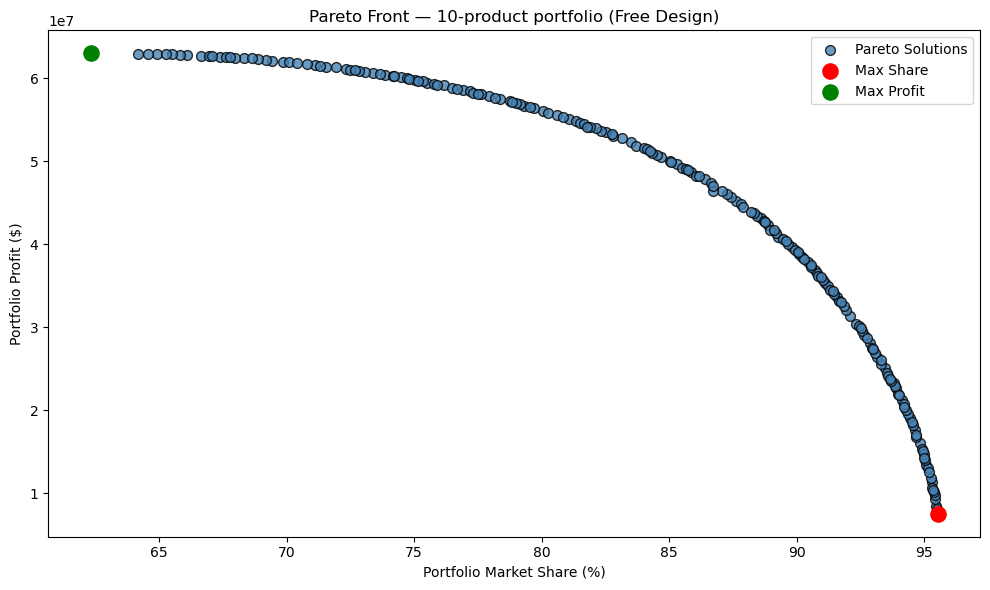

In [14]:
# ── CELL 5 — Pareto Front Plot ────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# --- Main scatter ---
ax.scatter(
    portfolio_shares,
    portfolio_profits,
    s          = 50,
    alpha      = 0.8,
    edgecolors = 'black',
    color      = 'steelblue',
    label      = 'Pareto Solutions'
)

# --- Mark the two extreme solutions ---
ax.scatter(
    portfolio_shares[best_share_idx],
    portfolio_profits[best_share_idx],
    color='red', s=120, zorder=5, label='Max Share'
)
ax.scatter(
    portfolio_shares[best_profit_idx],
    portfolio_profits[best_profit_idx],
    color='green', s=120, zorder=5, label='Max Profit'
)

ax.set_xlabel("Portfolio Market Share (%)")
ax.set_ylabel("Portfolio Profit ($)")
ax.set_title(f"Pareto Front — {NUM_PRODUCTS}-product portfolio (Free Design)")
ax.legend()

plt.tight_layout()
# --- Save the graph ---
# Generate a unique timestamp for the filename
timestamp = time.strftime("%Y%m%d-%H%M%S")
filename = f"pareto_run_{timestamp}.png"

# Save the figure (dpi=300 ensures high quality)
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Graph saved as: {filename}")
plt.show()